In [3]:
#Packages 
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmo
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
warnings.filterwarnings("ignore") #turns off annoying warnings
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LinearSegmentedColormap
import os
from collections import defaultdict

In [2]:
import os
import numpy as np
from collections import defaultdict

output_dir = '../mixing_outputs/'

def parse_resolution(res_str):
    if res_str.endswith('km'):
        return float(res_str.replace('km', '')) * 1000  # convert km to meters
    elif res_str.endswith('m'):
        return float(res_str.replace('m', ''))         # meters as is
    else:
        raise ValueError(f"Unknown resolution unit in '{res_str}'")

# === Step 1: Scan all files ===
all_files = os.listdir(output_dir)

# Group files by (hres, zres)
grouped_files = defaultdict(lambda: {'mnum': [], 'mphy': []})

for fname in all_files:
    if not fname.endswith('.npy'):
        continue
    parts = fname.replace('.npy', '').split('_')

    if len(parts) < 5:
        continue  # Unexpected file name format

    kind = parts[0]  # mnum or mphy
    hres = parts[3]
    zres = parts[4]

    if kind == 'mnum':
        grouped_files[(hres, zres)]['mnum'].append(fname)
    elif kind == 'mphy':
        grouped_files[(hres, zres)]['mphy'].append(fname)

# === Step 2: Process each valid combo ===
results = {}

for (hres, zres), files in sorted(grouped_files.items()):
    # 🚫 Skip 100m resolution
    # if hres == '100m':
        # print(f"⏭ Skipping {hres}, {zres} — explicitly excluded")
        # continue

    mnum_files = sorted(files['mnum'])
    mphy_files = sorted(files['mphy'])

    if not mnum_files or not mphy_files:
        print(f"❌ Skipping {hres}, {zres} — missing one of the datasets")
        continue

    # Sum over time chunks
    mnum_sum_total = 0
    mnum_abs_sum_total = 0
    mphy_sum_total = 0

    for num_file in mnum_files:
        try:
            mnum = np.load(os.path.join(output_dir, num_file))
            mnum_sum_total += mnum.sum()
            mnum_abs_sum_total += np.abs(mnum).sum()
        except Exception as e:
            print(f"⚠️ Skipping corrupted mnum file {num_file}: {e}")

    for phy_file in mphy_files:
        try:
            mphy = np.load(os.path.join(output_dir, phy_file))
            mphy_sum_total += mphy.sum()
        except Exception as e:
            print(f"⚠️ Skipping corrupted mphy file {phy_file}: {e}")

    try:
        ratio = (mnum_sum_total / mphy_sum_total) * 100
        ratio_abs = (mnum_abs_sum_total / abs(mphy_sum_total)) * 100
    except ZeroDivisionError:
        ratio = np.nan
        ratio_abs = np.nan

    print(f"✔ {hres}, {zres}: ratio = {ratio:.2f}%, abs ratio = {ratio_abs:.2f}%")

    if zres not in results:
        results[zres] = {
            'x': [],
            'y': [],
            'y1': [],
            'mnum_sum': [],
            'mnum_abs_sum': [],
            'mphy_sum': []
        }

    results[zres]['x'].append(parse_resolution(hres))
    results[zres]['y'].append(ratio)
    results[zres]['y1'].append(ratio_abs)
    results[zres]['mnum_sum'].append(mnum_sum_total)
    results[zres]['mnum_abs_sum'].append(mnum_abs_sum_total)
    results[zres]['mphy_sum'].append(mphy_sum_total)


✔ 100m, z50: ratio = 5.32%, abs ratio = 5.32%
✔ 10km, z10: ratio = 138.53%, abs ratio = 138.68%
✔ 10km, z100: ratio = 52.06%, abs ratio = 52.70%
✔ 10km, z5: ratio = 248.51%, abs ratio = 248.59%
✔ 10km, z50: ratio = 49.09%, abs ratio = 53.36%
✔ 1km, z10: ratio = 110.35%, abs ratio = 110.40%
✔ 1km, z100: ratio = -2.43%, abs ratio = 5.68%
✔ 1km, z5: ratio = 371.81%, abs ratio = 371.85%
✔ 1km, z50: ratio = -1.27%, abs ratio = 6.90%
✔ 200m, z100: ratio = 2.35%, abs ratio = 2.35%
✔ 200m, z50: ratio = 4.62%, abs ratio = 4.62%
✔ 2km, z10: ratio = 87.11%, abs ratio = 87.22%
✔ 2km, z100: ratio = -0.26%, abs ratio = 9.87%
✔ 2km, z5: ratio = 307.88%, abs ratio = 307.96%
✔ 2km, z50: ratio = 0.16%, abs ratio = 9.56%
✔ 300m, z100: ratio = -3.95%, abs ratio = 4.95%
✔ 300m, z50: ratio = 0.27%, abs ratio = 2.88%
✔ 3km, z10: ratio = 88.76%, abs ratio = 88.90%
✔ 3km, z100: ratio = 1.44%, abs ratio = 12.76%
✔ 3km, z5: ratio = 260.36%, abs ratio = 260.45%
✔ 3km, z50: ratio = -0.16%, abs ratio = 16.08%
✔ 400

In [5]:
# Marker and color setup
markers = {'z5': 'x', 'z10': 'x', 'z50': 'x', 'z100': 'x'}
colors = {'z5': 'magenta', 'z10': 'blue', 'z50': 'black', 'z100': 'red'}

# Legend labels
label_map = { 
    'z5': '$dz$= 10 m',
    'z10': '$dz$= 5 m',
    'z50': '$dz$= 1 m',
    'z100': '$dz$= 0.5 m'
}
label_map_abs = {
    'z5': '$dz$= 10 m (abs val)',
    'z10': '$dz$= 5 m (abs val)',
    'z50': '$dz$= 1 m (abs val)',
    'z100': '$dz$= 0.5 m (abs val)'
}

plot_order = ['z5', 'z10', 'z50', 'z100']

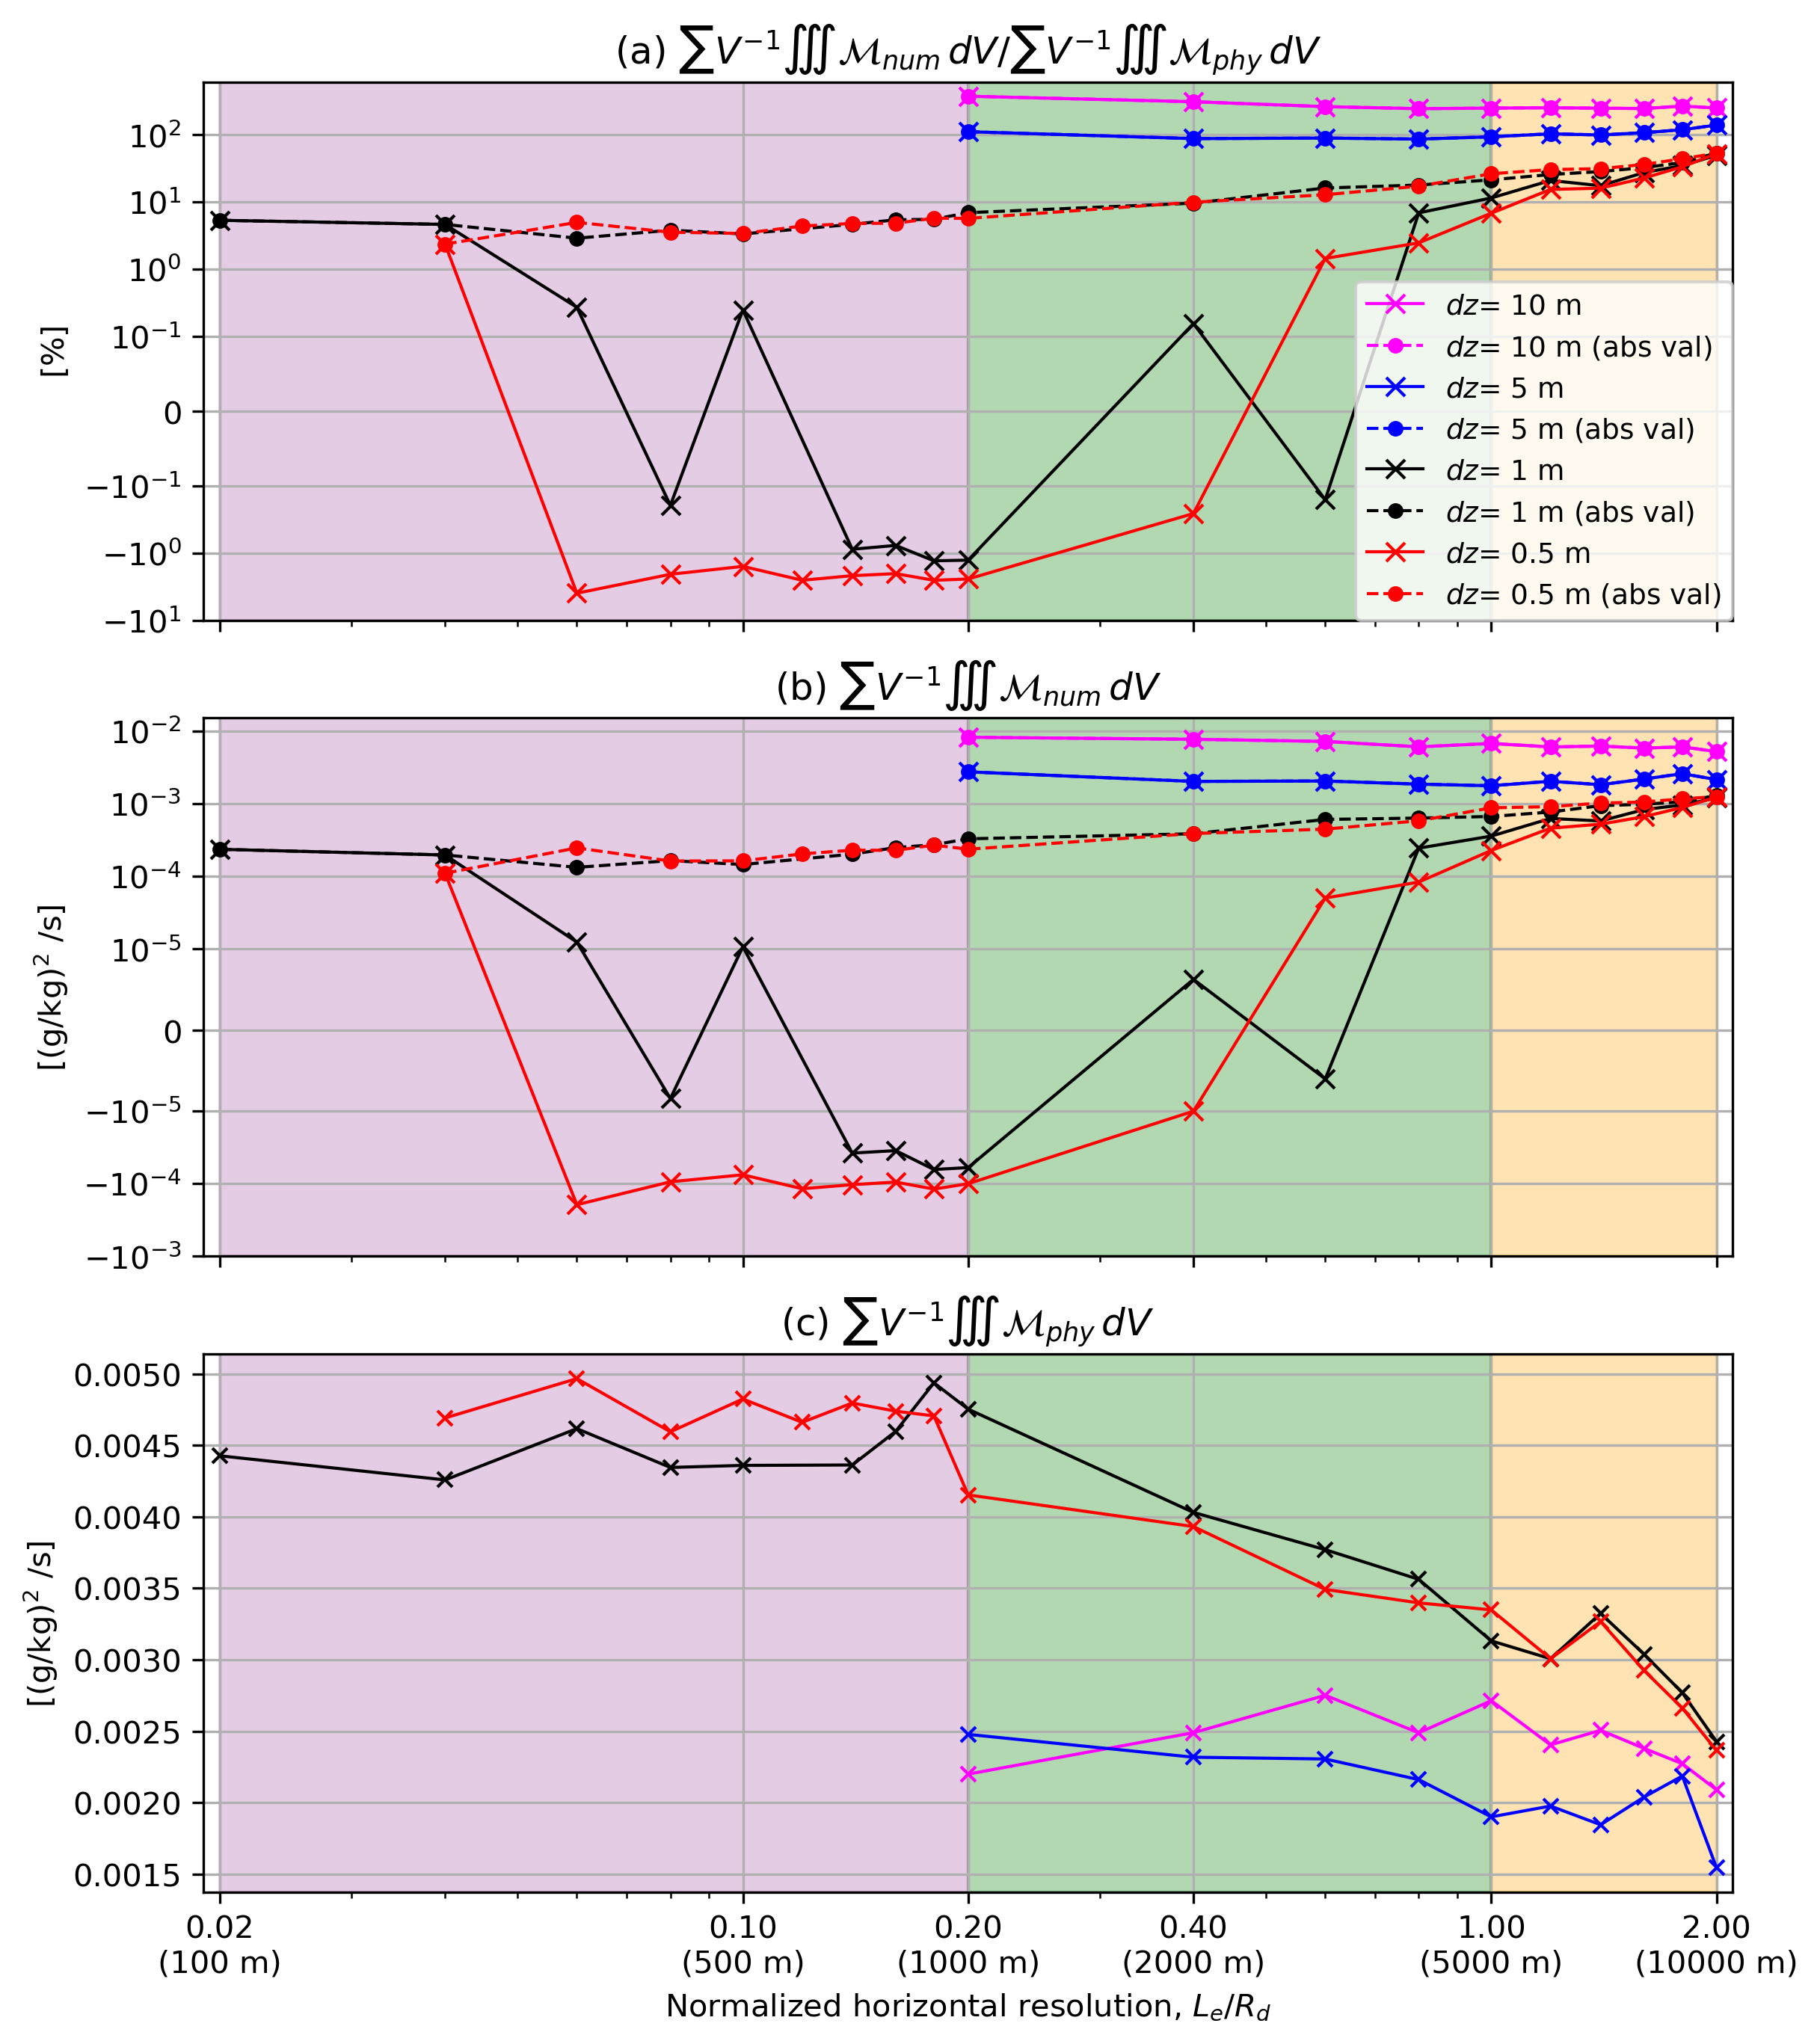

In [4]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 9), constrained_layout=True, dpi=300)
linthresh = 1e-1
all_lines, all_labels = [], []

for zres in plot_order:
    data = results[zres]
    # Normalize x by dividing by 5000
    x_norm = np.array(data['x']) / 5000
    
    sorted_data = sorted(zip(x_norm, data['y']))
    sorted_data_abs = sorted(zip(x_norm, data['y1']))
    sorted_mnum = sorted(zip(x_norm, data['mnum_sum']))
    sorted_mnum_abs = sorted(zip(x_norm, data['mnum_abs_sum']))
    sorted_mphy = sorted(zip(x_norm, data['mphy_sum']))

    x_sorted, y_sorted = zip(*sorted_data)
    _, y_sorted_abs = zip(*sorted_data_abs)
    _, y_mnum = zip(*sorted_mnum)
    _, y_mnum_abs = zip(*sorted_mnum_abs)
    _, y_mphy = zip(*sorted_mphy)

    # Plot on ax[0]
    line1, = ax[0].plot(x_sorted, y_sorted, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    line2, = ax[0].plot(x_sorted, y_sorted_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)
    all_lines.extend([line1, line2])
    all_labels.extend([label_map[zres], label_map_abs[zres]])


    # Plot on ax[1]
    ax[1].plot(x_sorted, y_mnum, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    ax[1].plot(x_sorted, y_mnum_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)

    # Plot on ax[2]
    ax[2].plot(x_sorted, y_mphy, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=5)

# Create normalized ticks from all x data
unique_x = sorted(set(x for z in results.values() for x in z['x']))
unique_x_normalized = [x / 5000 for x in unique_x]

ticks_to_show = [0.02, 0.1, 0.2, 0.4, 1.0, 2.0]

for i in range(3):
    ax[i].grid(True)
    ax[i].set_xlabel('Normalized horizontal resolution, $L_e/R_d$')
    ax[i].semilogx()
    ax[i].set_xlim(0.015, 2.1)
    ax[i].set_xticks(ticks_to_show)
    # ax[i].set_xticklabels([f"{val:.2f}" for val in ticks_to_show])
    ax[i].set_xticklabels([
    f"{val:.2f}\n({int(val * 5000)} m)" for val in ticks_to_show])
    # Add secondary x-axis for resolution in meters

    ax[i].axvspan(1, 2, color='orange', alpha=0.3)
    ax[i].axvspan(0.2, 1, color='green', alpha=0.3)
    ax[i].axvspan(0.02, 0.2, color='purple', alpha=0.2)


# Axis-specific formatting
ax[0].set_yscale('symlog', linthresh=linthresh)
ax[0].set_title(r'(a) $\sum V^{-1} \iiint \mathcal{M}_{num} \, dV /  \sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[0].set_ylabel(r'[$\%$]')
ax[0].set_xticklabels([])
ax[0].set_xlabel('')

ax[0].set_ylim(-10,600)

ax[1].set_xticklabels([])
ax[1].set_xlabel('')
ax[1].set_title(r'(b) $\sum V^{-1} \iiint \mathcal{M}_{num} \, dV$')
ax[1].set_ylabel(r'[(g/kg)$^2$ /s]')
ax[1].set_yscale('symlog', linthresh=1e-5)
ax[1].set_ylim(-.001,.015)

ax[2].set_title(r'(c) $\sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[2].set_ylabel(r'[(g/kg)$^2$ /s]')

ax[0].set_xlim(0.019,2.1)
ax[1].set_xlim(0.019,2.1)
ax[2].set_xlim(0.019,2.1)

ax[0].legend(all_lines, all_labels,loc='lower right', fontsize=9, borderaxespad=0)

fig.subplots_adjust(right=0.75)
# plt.savefig('scatter_plots_bichan_hvres.png', dpi=500)


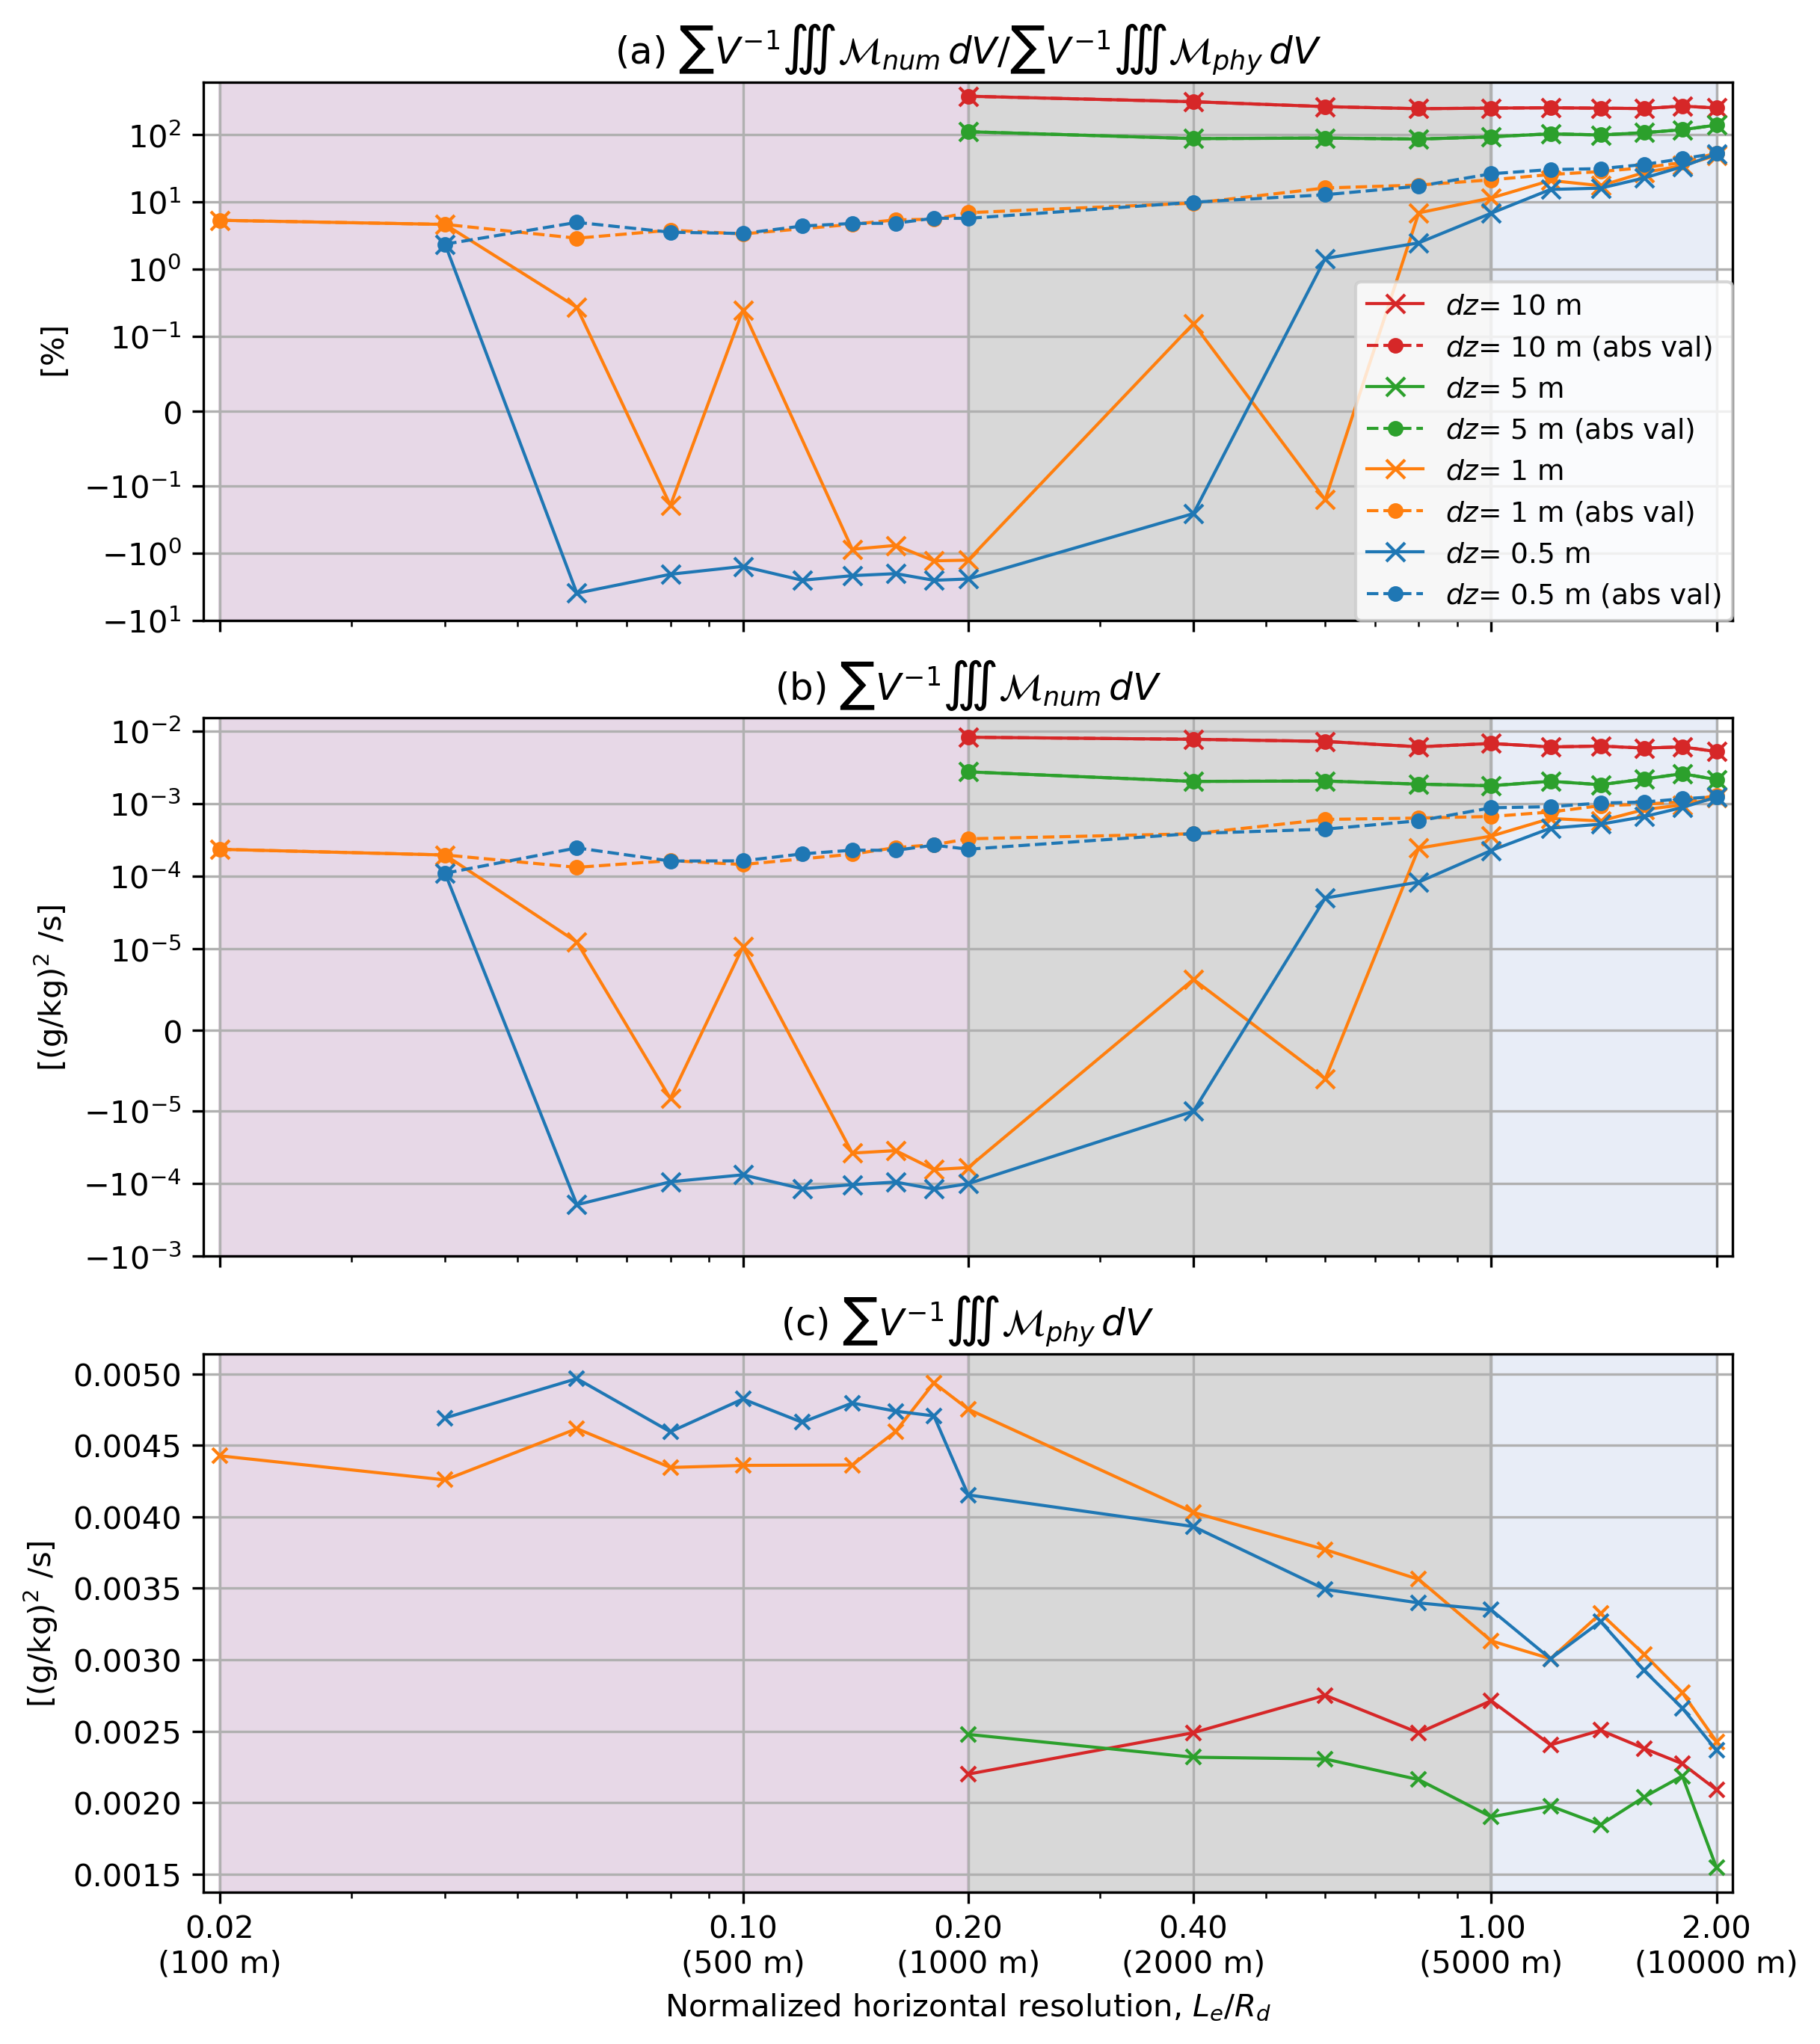

In [5]:
# Marker and color setup
markers = {'z5': 'x', 'z10': 'x', 'z50': 'x', 'z100': 'x'}
colors = {'z5': 'tab:red', 'z10': 'tab:green', 'z50': 'tab:orange', 'z100': 'tab:blue'}

# Legend labels
label_map = { 
    'z5': '$dz$= 10 m',
    'z10': '$dz$= 5 m',
    'z50': '$dz$= 1 m',
    'z100': '$dz$= 0.5 m'
}
label_map_abs = {
    'z5': '$dz$= 10 m (abs val)',
    'z10': '$dz$= 5 m (abs val)',
    'z50': '$dz$= 1 m (abs val)',
    'z100': '$dz$= 0.5 m (abs val)'
}

plot_order = ['z5', 'z10', 'z50', 'z100']
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 9), constrained_layout=True, dpi=300)
linthresh = 1e-1
all_lines, all_labels = [], []

for zres in plot_order:
    data = results[zres]
    # Normalize x by dividing by 5000
    x_norm = np.array(data['x']) / 5000
    
    sorted_data = sorted(zip(x_norm, data['y']))
    sorted_data_abs = sorted(zip(x_norm, data['y1']))
    sorted_mnum = sorted(zip(x_norm, data['mnum_sum']))
    sorted_mnum_abs = sorted(zip(x_norm, data['mnum_abs_sum']))
    sorted_mphy = sorted(zip(x_norm, data['mphy_sum']))

    x_sorted, y_sorted = zip(*sorted_data)
    _, y_sorted_abs = zip(*sorted_data_abs)
    _, y_mnum = zip(*sorted_mnum)
    _, y_mnum_abs = zip(*sorted_mnum_abs)
    _, y_mphy = zip(*sorted_mphy)

    # Plot on ax[0]
    line1, = ax[0].plot(x_sorted, y_sorted, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    line2, = ax[0].plot(x_sorted, y_sorted_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)
    all_lines.extend([line1, line2])
    all_labels.extend([label_map[zres], label_map_abs[zres]])


    # Plot on ax[1]
    ax[1].plot(x_sorted, y_mnum, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    ax[1].plot(x_sorted, y_mnum_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)

    # Plot on ax[2]
    ax[2].plot(x_sorted, y_mphy, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=5)

# Create normalized ticks from all x data
unique_x = sorted(set(x for z in results.values() for x in z['x']))
unique_x_normalized = [x / 5000 for x in unique_x]

ticks_to_show = [0.02, 0.1, 0.2, 0.4, 1.0, 2.0]

for i in range(3):
    ax[i].grid(True)
    ax[i].set_xlabel('Normalized horizontal resolution, $L_e/R_d$')
    ax[i].semilogx()
    ax[i].set_xlim(0.015, 2.1)
    ax[i].set_xticks(ticks_to_show)
    # ax[i].set_xticklabels([f"{val:.2f}" for val in ticks_to_show])
    ax[i].set_xticklabels([
    f"{val:.2f}\n({int(val * 5000)} m)" for val in ticks_to_show])
    # Add secondary x-axis for resolution in meters

    ax[i].axvspan(1, 2, color='#c7d3ec', alpha=0.4)
    ax[i].axvspan(0.2, 1, color='gray', alpha=0.3)
    ax[i].axvspan(0.02, 0.2, color='#d8bfd8', alpha=0.6)


# Axis-specific formatting
ax[0].set_yscale('symlog', linthresh=linthresh)
ax[0].set_title(r'(a) $\sum V^{-1} \iiint \mathcal{M}_{num} \, dV /  \sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[0].set_ylabel(r'[$\%$]')
ax[0].set_xticklabels([])
ax[0].set_xlabel('')

ax[0].set_ylim(-10,600)

ax[1].set_xticklabels([])
ax[1].set_xlabel('')
ax[1].set_title(r'(b) $\sum V^{-1} \iiint \mathcal{M}_{num} \, dV$')
ax[1].set_ylabel(r'[(g/kg)$^2$ /s]')
ax[1].set_yscale('symlog', linthresh=1e-5)
ax[1].set_ylim(-.001,.015)

ax[2].set_title(r'(c) $\sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[2].set_ylabel(r'[(g/kg)$^2$ /s]')

ax[0].set_xlim(0.019,2.1)
ax[1].set_xlim(0.019,2.1)
ax[2].set_xlim(0.019,2.1)

ax[0].legend(all_lines, all_labels,loc='lower right', fontsize=9, borderaxespad=0)

fig.subplots_adjust(right=0.75)
plt.savefig('scatter_plots_bichan_hvres.png', dpi=500)


### Now add the total mixing 

In [1]:
import os
import numpy as np
from collections import defaultdict

output_dir = '../mixing_outputs/'

def parse_resolution(res_str):
    if res_str.endswith('km'):
        return float(res_str.replace('km', '')) * 1000  # convert km to meters
    elif res_str.endswith('m'):
        return float(res_str.replace('m', ''))         # meters as is
    else:
        raise ValueError(f"Unknown resolution unit in '{res_str}'")

# === Step 1: Scan all files ===
all_files = os.listdir(output_dir)

# Group files by (hres, zres)
grouped_files = defaultdict(lambda: {'mnum': [], 'mphy': [], 'mtot': []})

for fname in all_files:
    if not fname.endswith('.npy'):
        continue
    parts = fname.replace('.npy', '').split('_')

    if len(parts) < 5:
        continue  # Unexpected file name format

    kind = parts[0]  # mnum, mphy, or mtot
    hres = parts[3]
    zres = parts[4]

    if kind in ['mnum', 'mphy', 'mtot']:
        grouped_files[(hres, zres)][kind].append(fname)

# === Step 2: Process each valid combo ===
results = {}

for (hres, zres), files in sorted(grouped_files.items()):
    mnum_files = sorted(files['mnum'])
    mphy_files = sorted(files['mphy'])
    mtot_files = sorted(files['mtot'])

    if not mnum_files or not mphy_files or not mtot_files:
        print(f"❌ Skipping {hres}, {zres} — missing one of the datasets")
        continue

    # Initialize sums
    mnum_sum_total = 0
    mnum_abs_sum_total = 0
    mphy_sum_total = 0
    mtot_sum_total = 0

    # --- Sum numerical mixing ---
    for num_file in mnum_files:
        try:
            mnum = np.load(os.path.join(output_dir, num_file))
            mnum_sum_total += mnum.sum()
            mnum_abs_sum_total += np.abs(mnum).sum()
        except Exception as e:
            print(f"⚠️ Skipping corrupted mnum file {num_file}: {e}")

    # --- Sum physical mixing ---
    for phy_file in mphy_files:
        try:
            mphy = np.load(os.path.join(output_dir, phy_file))
            mphy_sum_total += mphy.sum()
        except Exception as e:
            print(f"⚠️ Skipping corrupted mphy file {phy_file}: {e}")

    # --- Sum total mixing ---
    for tot_file in mtot_files:
        try:
            mtot = np.load(os.path.join(output_dir, tot_file))
            mtot_sum_total += mtot.sum()
        except Exception as e:
            print(f"⚠️ Skipping corrupted mtot file {tot_file}: {e}")

    # Compute ratios
    try:
        ratio = (mnum_sum_total / mphy_sum_total) * 100
        ratio_abs = (mnum_abs_sum_total / abs(mphy_sum_total)) * 100
    except ZeroDivisionError:
        ratio = np.nan
        ratio_abs = np.nan

    print(f"✔ {hres}, {zres}: ratio = {ratio:.2f}%, abs ratio = {ratio_abs:.2f}%, mtot_sum = {mtot_sum_total:.3e}")

    # --- Store results ---
    if zres not in results:
        results[zres] = {
            'x': [],
            'y': [],
            'y1': [],
            'mnum_sum': [],
            'mnum_abs_sum': [],
            'mphy_sum': [],
            'mtot_sum': []
        }

    results[zres]['x'].append(parse_resolution(hres))
    results[zres]['y'].append(ratio)
    results[zres]['y1'].append(ratio_abs)
    results[zres]['mnum_sum'].append(mnum_sum_total)
    results[zres]['mnum_abs_sum'].append(mnum_abs_sum_total)
    results[zres]['mphy_sum'].append(mphy_sum_total)
    results[zres]['mtot_sum'].append(mtot_sum_total)


❌ Skipping 100m, z50 — missing one of the datasets
✔ 10km, z10: ratio = 138.53%, abs ratio = 138.68%, mtot_sum = 3.681e-03
✔ 10km, z100: ratio = 52.06%, abs ratio = 52.70%, mtot_sum = 3.595e-03
✔ 10km, z5: ratio = 248.51%, abs ratio = 248.59%, mtot_sum = 7.282e-03
✔ 10km, z50: ratio = 49.09%, abs ratio = 53.36%, mtot_sum = 3.618e-03
✔ 1km, z10: ratio = 110.35%, abs ratio = 110.40%, mtot_sum = 5.211e-03
❌ Skipping 1km, z100 — missing one of the datasets
✔ 1km, z5: ratio = 371.81%, abs ratio = 371.85%, mtot_sum = 1.038e-02
✔ 1km, z50: ratio = -1.27%, abs ratio = 6.90%, mtot_sum = 4.693e-03
❌ Skipping 200m, z100 — missing one of the datasets
❌ Skipping 200m, z50 — missing one of the datasets
✔ 2km, z10: ratio = 87.11%, abs ratio = 87.22%, mtot_sum = 4.336e-03
✔ 2km, z100: ratio = -0.26%, abs ratio = 9.87%, mtot_sum = 3.922e-03
✔ 2km, z5: ratio = 307.88%, abs ratio = 307.96%, mtot_sum = 1.015e-02
✔ 2km, z50: ratio = 0.16%, abs ratio = 9.56%, mtot_sum = 4.037e-03
❌ Skipping 300m, z100 — mis

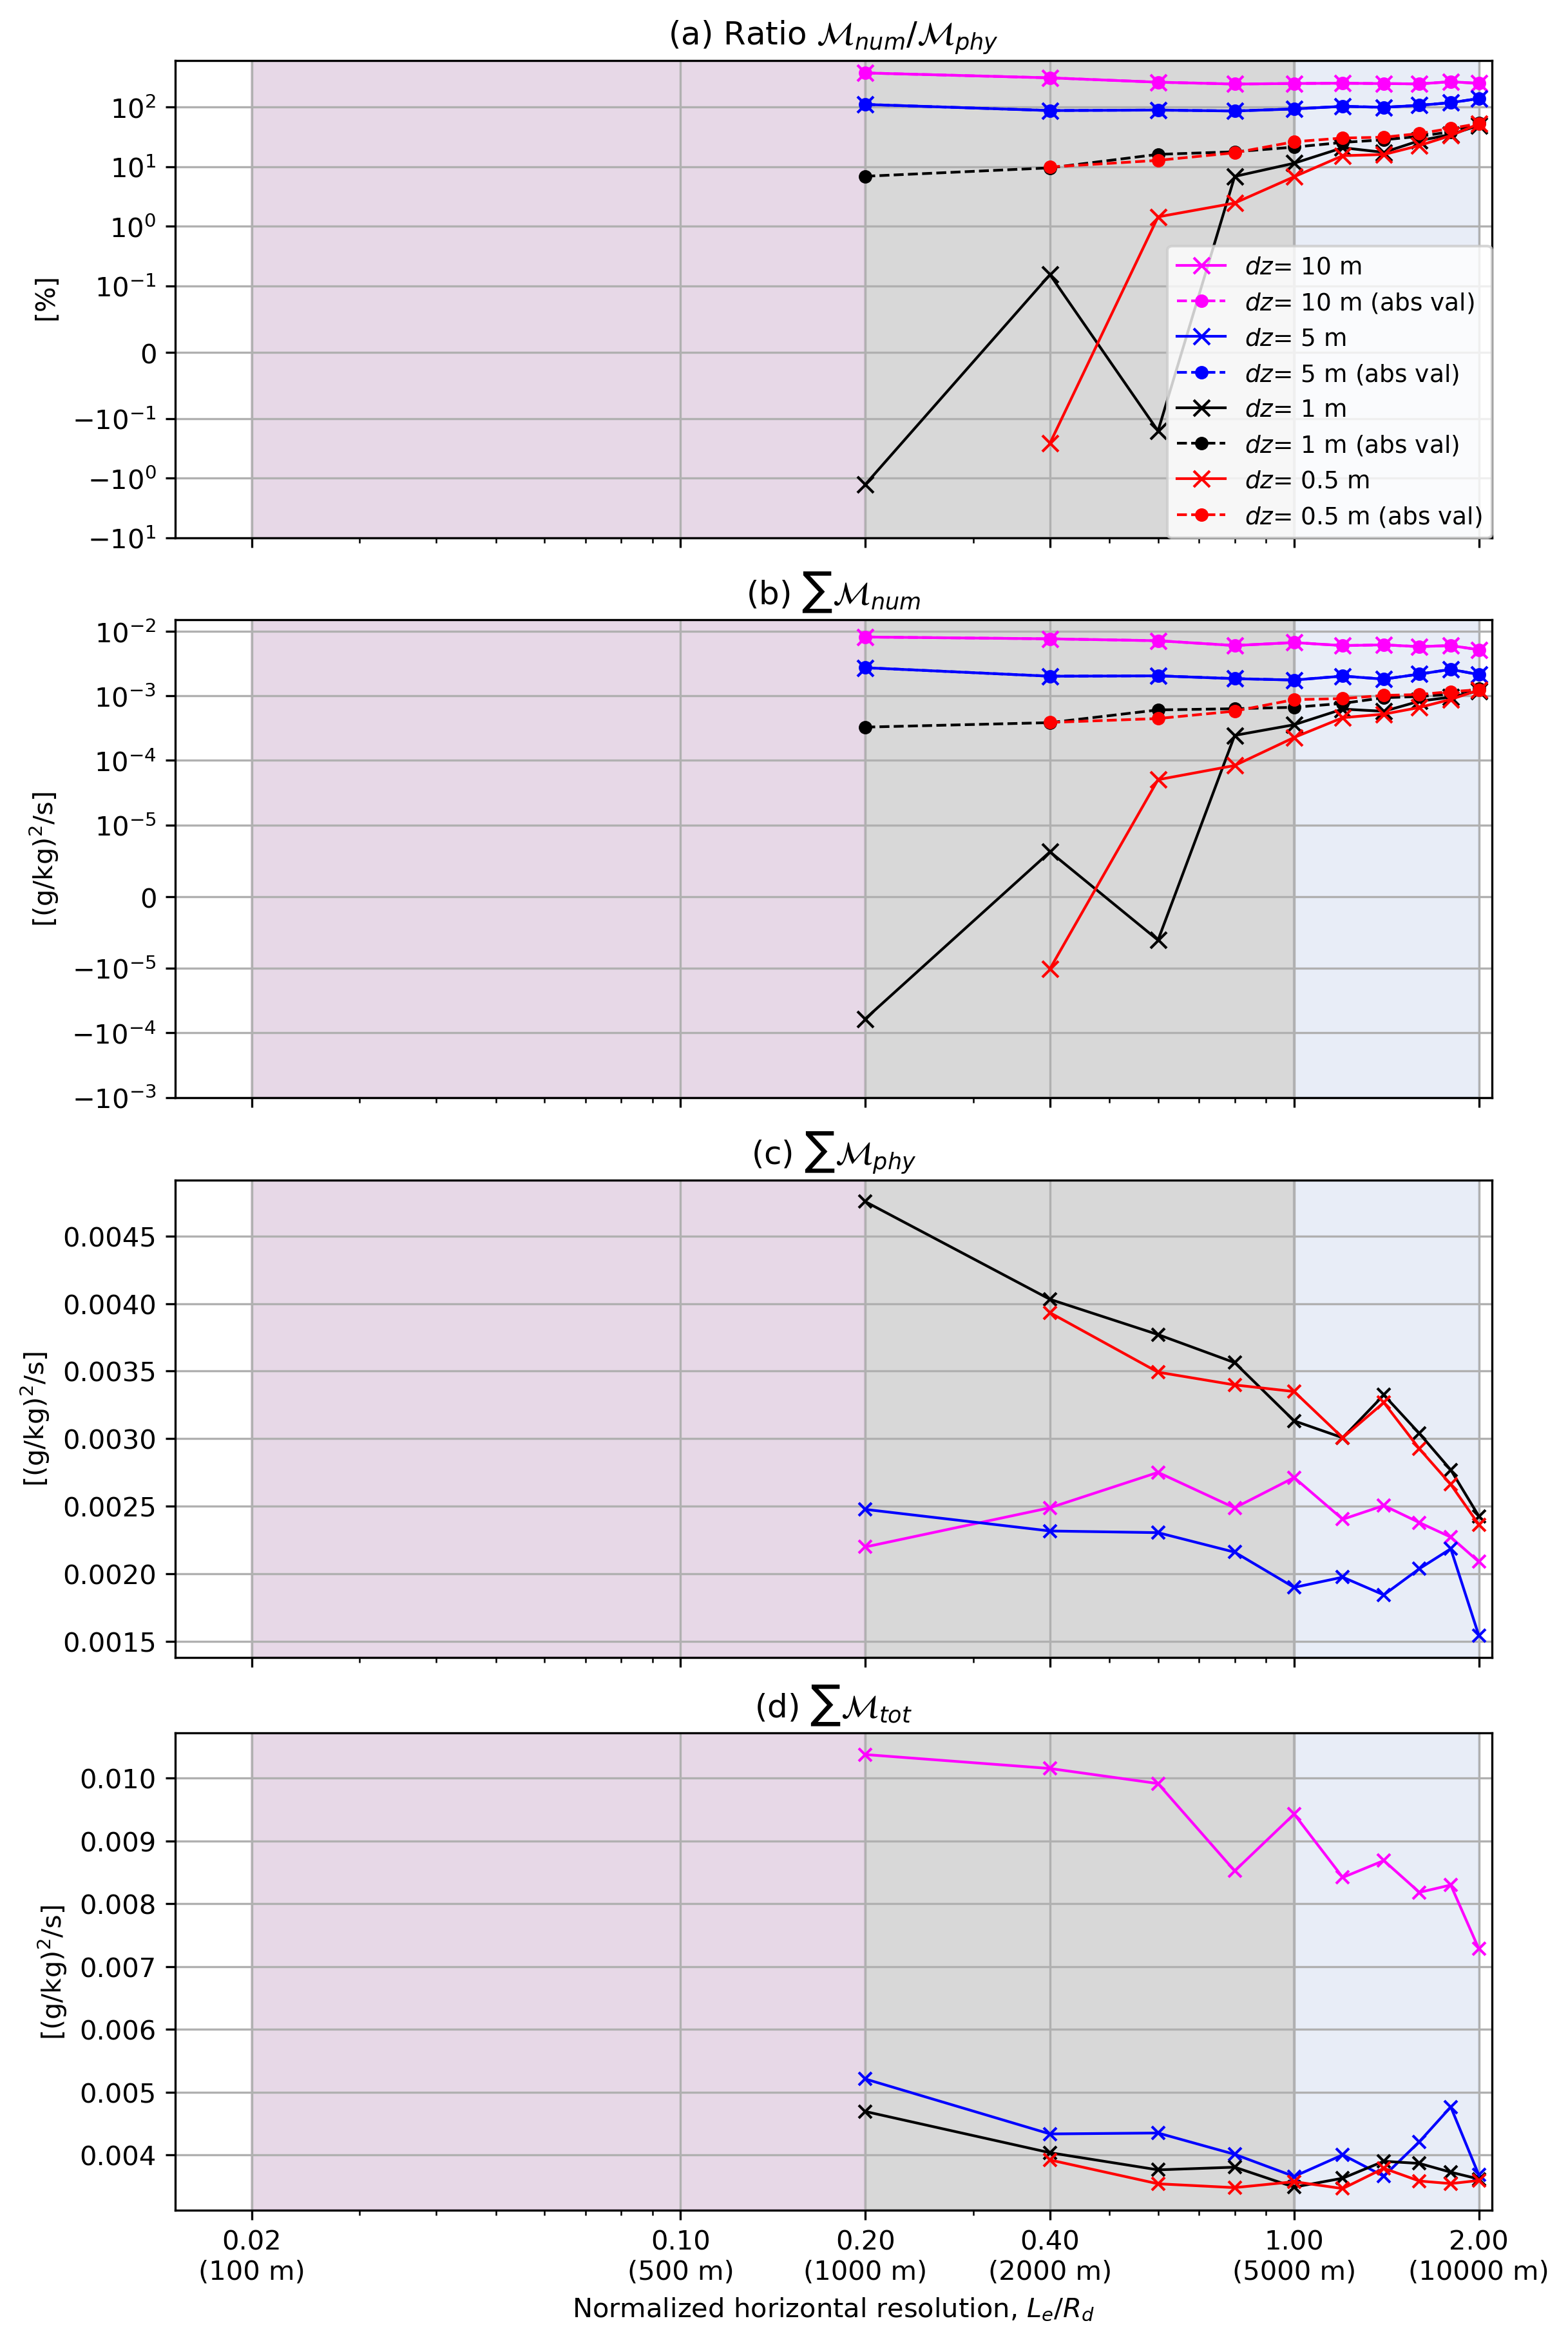

In [10]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(8, 12), constrained_layout=True, dpi=300)
linthresh = 1e-1
all_lines, all_labels = [], []

for zres in plot_order:
    data = results[zres]
    x_norm = np.array(data['x']) / 5000
    
    sorted_data = sorted(zip(x_norm, data['y']))
    sorted_data_abs = sorted(zip(x_norm, data['y1']))
    sorted_mnum = sorted(zip(x_norm, data['mnum_sum']))
    sorted_mnum_abs = sorted(zip(x_norm, data['mnum_abs_sum']))
    sorted_mphy = sorted(zip(x_norm, data['mphy_sum']))
    sorted_mtot = sorted(zip(x_norm, data['mtot_sum']))  # <--- mtot

    x_sorted, y_sorted = zip(*sorted_data)
    _, y_sorted_abs = zip(*sorted_data_abs)
    _, y_mnum = zip(*sorted_mnum)
    _, y_mnum_abs = zip(*sorted_mnum_abs)
    _, y_mphy = zip(*sorted_mphy)
    _, y_mtot = zip(*sorted_mtot)  # <--- mtot

    # Plot on ax[0]
    line1, = ax[0].plot(x_sorted, y_sorted, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    line2, = ax[0].plot(x_sorted, y_sorted_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)
    all_lines.extend([line1, line2])
    all_labels.extend([label_map[zres], label_map_abs[zres]])

    # Plot on ax[1]
    ax[1].plot(x_sorted, y_mnum, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=6)
    ax[1].plot(x_sorted, y_mnum_abs, marker='o', linestyle='--', color=colors[zres], lw=1, markersize=4)

    # Plot on ax[2]
    ax[2].plot(x_sorted, y_mphy, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=5)

    # Plot on ax[3] for total mixing
    ax[3].plot(x_sorted, y_mtot, marker=markers[zres], linestyle='-', color=colors[zres], lw=1, markersize=5)

# --- Axis formatting for all 4 axes ---
ticks_to_show = [0.02, 0.1, 0.2, 0.4, 1.0, 2.0]
for i in range(4):
    ax[i].grid(True)
    ax[i].set_xlabel('Normalized horizontal resolution, $L_e/R_d$')
    ax[i].semilogx()
    ax[i].set_xlim(0.015, 2.1)
    ax[i].set_xticks(ticks_to_show)
    ax[i].set_xticklabels([f"{val:.2f}\n({int(val*5000)} m)" for val in ticks_to_show])
    ax[i].axvspan(1, 2, color='#c7d3ec', alpha=0.4)
    ax[i].axvspan(0.2, 1, color='gray', alpha=0.3)
    ax[i].axvspan(0.02, 0.2, color='#d8bfd8', alpha=0.6)

# Titles and Y-labels
ax[0].set_title(r'(a) Ratio $\mathcal{M}_{num}/\mathcal{M}_{phy}$'); ax[0].set_ylabel('[$\%$]'); ax[0].set_yscale('symlog', linthresh=linthresh); ax[0].set_ylim(-10, 600)
ax[1].set_title(r'(b) $\sum \mathcal{M}_{num}$'); ax[1].set_ylabel('[(g/kg)$^2$/s]'); ax[1].set_yscale('symlog', linthresh=1e-5); ax[1].set_ylim(-.001,.015)
ax[2].set_title(r'(c) $\sum \mathcal{M}_{phy}$'); ax[2].set_ylabel('[(g/kg)$^2$/s]')
ax[3].set_title(r'(d) $\sum \mathcal{M}_{tot}$'); ax[3].set_ylabel('[(g/kg)$^2$/s]')

for i in range(3):
    ax[i].set_xlabel('')
    ax[i].set_xticklabels('')

# Legends
ax[0].legend(all_lines, all_labels, loc='lower right', fontsize=9, borderaxespad=0)

fig.subplots_adjust(right=0.75)
# plt.savefig('scatter_plots_bichan_hvres_with_mtot.png', dpi=500)
